<a href="https://colab.research.google.com/github/rohanlambar/machine_learning_course/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('new.csv')
df

,x,y
0,28,424
1,19,403
2,7,369
3,17,369
4,33,363
5,56,316
6,80,339
7,130,335
8,110,383
9,71,382


In [ ]:
X = df['x']
X

NameError: name 'df' is not defined

In [ ]:
y = df['y']
y


NameError: name 'df' is not defined

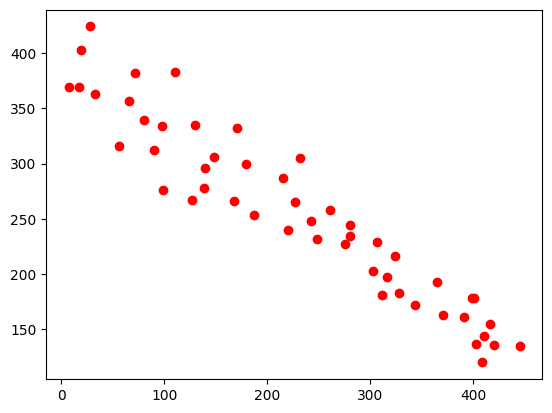

In [ ]:
plt.scatter(X,y,color='r',marker='o')

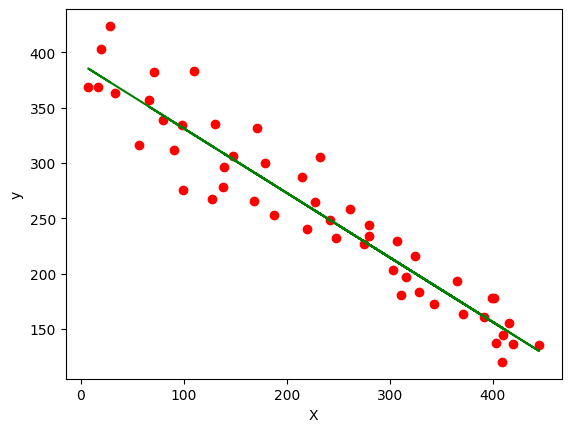

In [ ]:

def cal_exp(X,y):
   X_mean = np.mean(X)
   y_mean = np.mean(y)
   n = np.size(X)
   SS_XX = np.sum(X*X) - n*X_mean*X_mean
   SS_Xy = np.sum(X*y) - n*X_mean*y_mean
   b_0 = SS_Xy/SS_XX
   b_1 = y_mean - b_0*X_mean
   return (b_0,b_1)

def scatterploting(X,y,b):
   plt.scatter(X,y,color='r',marker='o')
   y_pred = b[0]*X + b[1]
   plt.plot(X,y_pred,color='g')
   plt.xlabel('X')
   plt.ylabel('y')

def main():
    b = cal_exp(X,y)
    scatterploting(X,y,b)

if __name__ =="__main__":
  main()


# **Multiple Linear Regression on Boston Housing Dataset **

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HousingData.csv to HousingData.csv


In [ ]:
import pandas as pd
df = pd.read_csv('HousingData.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
all_nan_columns = df.columns[df.isnull().any()].tolist()

# removing rows with nan values

df = df.dropna(subset=all_nan_columns)
df.isnull().sum()


['CRIM', 'ZN', 'INDUS', 'CHAS', 'AGE', 'LSTAT']

In [ ]:
# making dependent and independent variable
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,0.17783,0.0,9.69,0.0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10
500,0.22438,0.0,9.69,0.0,0.585,6.027,79.7,2.4982,6,391,19.2,396.90,14.33
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64


In [ ]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3 , random_state = 12)



In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 275 entries, 461 to 424
Series name: MEDV
Non-Null Count  Dtype  
--------------  -----  
275 non-null    float64
dtypes: float64(1)
memory usage: 4.3 KB


In [ ]:
# training model  linear model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
# predicting y
y_pred = model.predict(X_test)



array([27.57435239, 25.17839344, 24.87951755, 24.90245579, 13.51823037,
       11.97245613, 19.25909204, 33.74159774, 19.70789095, 28.48470064,
       24.16668862, 11.05477079, 13.17004319, 25.13619962, 14.74738337,
       14.90530337, 20.9339376 , 21.30938547, 26.14932151, 21.6593096 ,
       16.07405031, 17.34637772, 20.28137419, 18.65077387, 19.25238386,
       22.93302606, 23.48855951, 12.11710882, 17.2542365 , 12.93630674,
       24.15863063, 18.27074052, 36.8265454 , 18.47056557, 29.70856389,
       43.9822651 , 29.68392656, 16.29385856, 20.27874124, 25.23865159,
        7.22389386, 16.16673205, 25.39624747, 19.11719309, 26.53254178,
       24.75178545, 18.8835574 , 17.46665713, 19.90872031, 12.8796924 ,
       17.24268632, 29.59195704, 20.36330328, 15.4903168 , 18.95934831,
       25.04037744, 38.51224826, 17.83181715, 13.81327878,  9.37043259,
       21.84990236, 22.68648823, 28.87527387, 21.92222865, 26.62368322,
       12.21965185, 17.33111835, 14.95952601, 30.67443932, 14.39

In [ ]:
#evaluting the model
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
score

0.8282052494362993

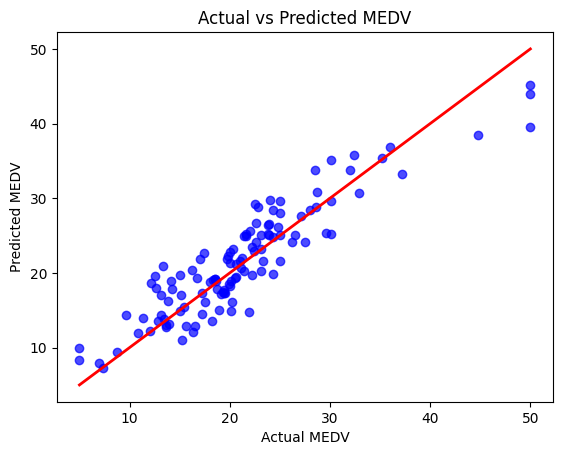

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted MEDV")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linewidth=2)  # Reference line
plt.show()